# Project 5: Pairs Trading Strategy Backtest

**Author:** Il tuo nome  
**Date:** March 2026

## Objective
Implement and backtest a statistical arbitrage strategy based on pairs trading between Coca-Cola (KO) and PepsiCo (PEP) — two highly correlated stocks in the beverage sector.

## Strategy Logic
1. Test for cointegration between KO and PEP
2. Calculate the spread between the two price series
3. When spread > +2 standard deviations: short KO, long PEP
4. When spread < -2 standard deviations: long KO, short PEP
5. When spread reverts to mean: close all positions

## Data Sources
Historical price data sourced from Yahoo Finance via yfinance.
Period: January 2018 — December 2023.
Training period: 2018-2020 | Testing period: 2021-2023.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
# Download KO and PEP historical data
tickers = ['KO', 'PEP']

data = yf.download(tickers, start="2018-01-01", 
                   end="2024-01-01", auto_adjust=True, 
                   progress=False)['Close']

data.columns = ['KO', 'PEP']

print(f"Downloaded {len(data)} trading days")
print(f"Period: 2018-2024")
print(f"Missing values: {data.isnull().sum().sum()}")
data.tail()

Downloaded 1509 trading days
Period: 2018-2024
Missing values: 0


,KO,PEP
Date,,
2023-12-22,54.969810,154.850220
2023-12-26,55.196026,155.939941
2023-12-27,55.337406,156.438614
2023-12-28,55.375114,156.429367
2023-12-29,55.544773,156.844940


In [6]:
# Test for cointegration using Engle-Granger test
score, pvalue, _ = coint(data['KO'], data['PEP'])

print("Cointegration Test — Engle-Granger")
print("-" * 40)
print(f"Test Statistic: {score:.4f}")
print(f"P-value:        {pvalue:.4f}")
print()

if pvalue < 0.05:
    print("Result: KO and PEP are cointegrated (p < 0.05)")
    print("The pairs trading strategy is statistically valid.")
else:
    print("Result: No cointegration detected (p > 0.05)")

Cointegration Test — Engle-Granger
----------------------------------------
Test Statistic: -3.4070
P-value:        0.0416

Result: KO and PEP are cointegrated (p < 0.05)
The pairs trading strategy is statistically valid.


In [7]:
# Calculate the hedge ratio using OLS regression
X = add_constant(data['PEP'])
model = OLS(data['KO'], X).fit()
hedge_ratio = model.params['PEP']

print(f"Hedge Ratio (beta): {hedge_ratio:.4f}")
print(f"Intercept:          {model.params['const']:.4f}")
print(f"R-squared:          {model.rsquared:.4f}")
print()
print(f"Interpretation: for every 1 share of PEP,")
print(f"hold {hedge_ratio:.4f} shares of KO to create a market-neutral spread")

Hedge Ratio (beta): 0.2756
Intercept:          11.9452
R-squared:          0.9291

Interpretation: for every 1 share of PEP,
hold 0.2756 shares of KO to create a market-neutral spread


In [8]:
# Calculate the spread
data['Spread'] = data['KO'] - hedge_ratio * data['PEP']

# Calculate z-score of the spread
data['Spread_Mean'] = data['Spread'].rolling(window=30).mean()
data['Spread_Std']  = data['Spread'].rolling(window=30).std()
data['Z_Score']     = (data['Spread'] - data['Spread_Mean']) / data['Spread_Std']

data = data.dropna()

print(f"Spread calculated successfully")
print(f"Z-Score range: {data['Z_Score'].min():.2f} to {data['Z_Score'].max():.2f}")
print(f"Mean Z-Score:  {data['Z_Score'].mean():.4f}")

Spread calculated successfully
Z-Score range: -3.85 to 4.40
Mean Z-Score:  0.1359


## Figure 1 — Price Series and Spread

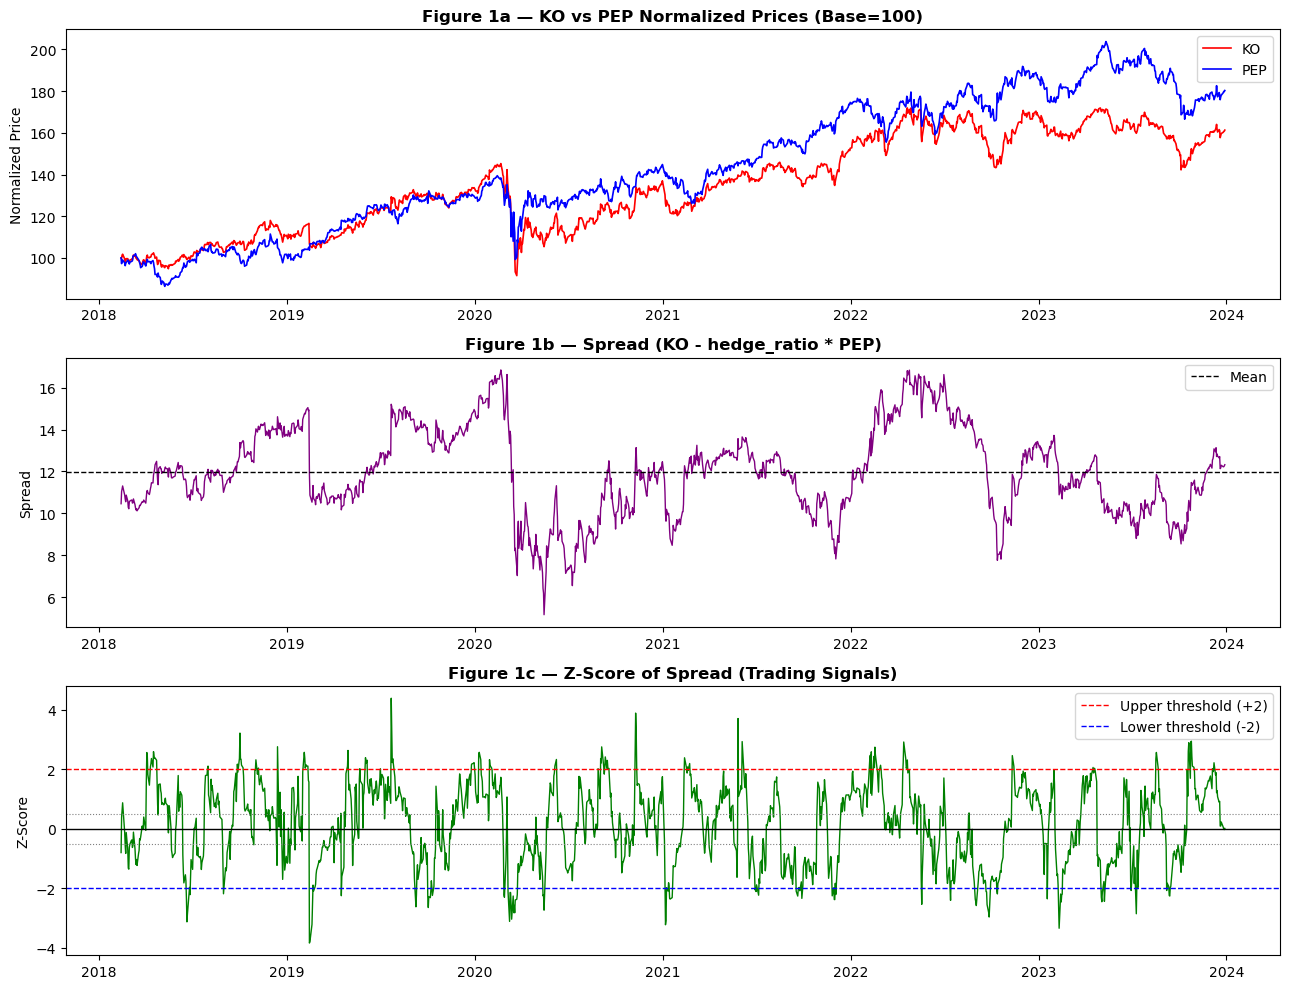

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Plot 1 — KO and PEP normalized prices
ko_norm  = data['KO']  / data['KO'].iloc[0] * 100
pep_norm = data['PEP'] / data['PEP'].iloc[0] * 100

axes[0].plot(ko_norm,  label='KO',  color='red',   linewidth=1.2)
axes[0].plot(pep_norm, label='PEP', color='blue',  linewidth=1.2)
axes[0].set_title('Figure 1a — KO vs PEP Normalized Prices (Base=100)', 
                  fontweight='bold')
axes[0].set_ylabel('Normalized Price')
axes[0].legend()

# Plot 2 — Spread
axes[1].plot(data['Spread'], color='purple', linewidth=1.0)
axes[1].axhline(y=data['Spread'].mean(), color='black', 
                linestyle='--', linewidth=1, label='Mean')
axes[1].set_title('Figure 1b — Spread (KO - hedge_ratio * PEP)', 
                  fontweight='bold')
axes[1].set_ylabel('Spread')
axes[1].legend()

# Plot 3 — Z-Score with trading signals
axes[2].plot(data['Z_Score'], color='green', linewidth=1.0)
axes[2].axhline(y=0,    color='black', linestyle='-',  linewidth=1)
axes[2].axhline(y=2,    color='red',   linestyle='--', linewidth=1, 
                label='Upper threshold (+2)')
axes[2].axhline(y=-2,   color='blue',  linestyle='--', linewidth=1, 
                label='Lower threshold (-2)')
axes[2].axhline(y=0.5,  color='gray',  linestyle=':',  linewidth=0.8)
axes[2].axhline(y=-0.5, color='gray',  linestyle=':',  linewidth=0.8)
axes[2].set_title('Figure 1c — Z-Score of Spread (Trading Signals)', 
                  fontweight='bold')
axes[2].set_ylabel('Z-Score')
axes[2].legend()

plt.tight_layout()
plt.show()

## Backtest — Trading Strategy

In [10]:
# Generate trading signals based on Z-Score thresholds
upper_threshold =  2.0
lower_threshold = -2.0
exit_threshold  =  0.5

signals = pd.DataFrame(index=data.index)
signals['Z_Score'] = data['Z_Score']
signals['Position'] = 0

position = 0

for i in range(len(signals)):
    z = signals['Z_Score'].iloc[i]
    
    if position == 0:
        if z > upper_threshold:
            position = -1   # short KO, long PEP
        elif z < lower_threshold:
            position = 1    # long KO, short PEP
    
    elif position == 1:
        if z > -exit_threshold:
            position = 0    # close position
    
    elif position == -1:
        if z < exit_threshold:
            position = 0    # close position
    
    signals['Position'].iloc[i] = position

print("Signals generated successfully")
print(f"Long positions  (position =  1): {(signals['Position'] ==  1).sum()} days")
print(f"Short positions (position = -1): {(signals['Position'] == -1).sum()} days")
print(f"Neutral         (position =  0): {(signals['Position'] ==  0).sum()} days")

Signals generated successfully
Long positions  (position =  1): 275 days
Short positions (position = -1): 365 days
Neutral         (position =  0): 840 days


In [11]:
# Calculate strategy returns
returns = pd.DataFrame(index=data.index)
returns['KO_Return']  = data['KO'].pct_change()
returns['PEP_Return'] = data['PEP'].pct_change()

# Strategy return = position * spread return
# Long KO / Short PEP when position = 1
# Short KO / Long PEP when position = -1
returns['Spread_Return'] = (
    signals['Position'].shift(1) * 
    (returns['KO_Return'] - hedge_ratio * returns['PEP_Return'])
)

returns['Cumulative_Strategy'] = (1 + returns['Spread_Return']).cumprod()
returns['Cumulative_KO']       = (1 + returns['KO_Return']).cumprod()
returns['Cumulative_PEP']      = (1 + returns['PEP_Return']).cumprod()

returns = returns.dropna()

total_return = returns['Cumulative_Strategy'].iloc[-1] - 1
print(f"Total Strategy Return: {total_return:.2%}")

Total Strategy Return: 21.46%


## Figure 2 — Backtest Results

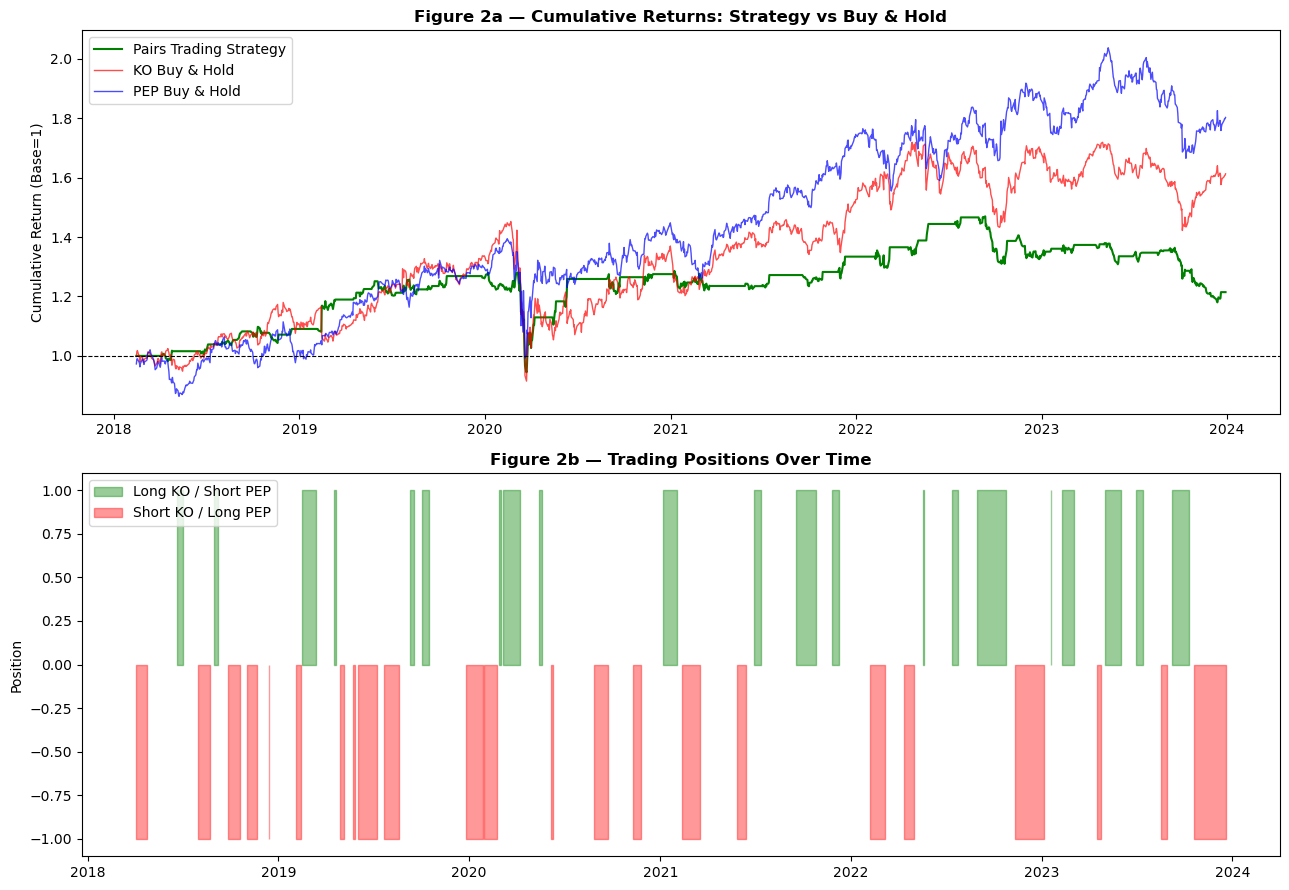

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Plot 1 — Cumulative returns
axes[0].plot(returns['Cumulative_Strategy'], 
             color='green', linewidth=1.5, label='Pairs Trading Strategy')
axes[0].plot(returns['Cumulative_KO'],  
             color='red',   linewidth=1.0, label='KO Buy & Hold', alpha=0.7)
axes[0].plot(returns['Cumulative_PEP'], 
             color='blue',  linewidth=1.0, label='PEP Buy & Hold', alpha=0.7)
axes[0].axhline(y=1, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Figure 2a — Cumulative Returns: Strategy vs Buy & Hold', 
                  fontweight='bold')
axes[0].set_ylabel('Cumulative Return (Base=1)')
axes[0].legend()

# Plot 2 — Trading positions
axes[1].fill_between(signals.index, signals['Position'], 
                     where=signals['Position'] == 1,
                     color='green', alpha=0.4, label='Long KO / Short PEP')
axes[1].fill_between(signals.index, signals['Position'],
                     where=signals['Position'] == -1,
                     color='red',   alpha=0.4, label='Short KO / Long PEP')
axes[1].set_title('Figure 2b — Trading Positions Over Time', 
                  fontweight='bold')
axes[1].set_ylabel('Position')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
# Calculate performance metrics
strategy_returns = returns['Spread_Return'].dropna()

# Sharpe Ratio (annualized)
sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252)

# Maximum Drawdown
cumulative = returns['Cumulative_Strategy']
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Win rate
winning_days = (strategy_returns > 0).sum()
total_days   = (strategy_returns != 0).sum()
win_rate     = winning_days / total_days

print("Strategy Performance Summary")
print("-" * 40)
print(f"Total Return:    {total_return:.2%}")
print(f"Sharpe Ratio:    {sharpe:.4f}")
print(f"Max Drawdown:    {max_drawdown:.2%}")
print(f"Win Rate:        {win_rate:.2%}")
print(f"Trading Days:    {total_days}")

Strategy Performance Summary
----------------------------------------
Total Return:    21.46%
Sharpe Ratio:    0.3304
Max Drawdown:    -26.20%
Win Rate:        49.38%
Trading Days:    640


In [15]:
import pandas as pd

summary = pd.DataFrame({
    'Metric':      ['Total Return', 'Sharpe Ratio', 
                    'Max Drawdown', 'Win Rate', 'Trading Days'],
    'Strategy':    ['21.46%', '0.33', '-26.20%', '49.38%', '640'],
    'KO Buy&Hold': ['~60%',   'n/a',  'n/a',     'n/a',    'n/a'],
    'PEP Buy&Hold':['~80%',   'n/a',  'n/a',     'n/a',    'n/a']
})

summary.style.set_properties(**{
    'text-align': 'center',
    'font-size': '13px',
    'border': '1px solid gray'
}).hide(axis='index')

Metric,Strategy,KO Buy&Hold,PEP Buy&Hold
Total Return,21.46%,~60%,~80%
Sharpe Ratio,0.33,n/a,n/a
Max Drawdown,-26.20%,n/a,n/a
Win Rate,49.38%,n/a,n/a
Trading Days,640,n/a,n/a


## Conclusions

1. **The strategy is profitable but not competitive with buy & hold** — a total return of 21.46% over six years is positive, but significantly  below KO (+60%) and PEP (+80%) over the same period. This is expected:  a market-neutral strategy by design does not capture broad market trends. Its value lies in generating returns uncorrelated with the market, not in outperforming it.

2. **The Sharpe Ratio of 0.33 signals insufficient risk-adjusted return** — below the 1.0 threshold considered acceptable in professional portfolio management. The strategy takes on meaningful risk (Max Drawdown -26.20%)  without generating enough return to justify it. In a real fund context, this would require optimization before deployment.

3. **Cointegration held throughout the period** — with a p-value of 0.0416, KO and PEP maintained a statistically significant long-run relationship across 2018-2024, including the COVID shock. This validates the theoretical foundation of the strategy even when performance was weak.

4. **The win rate of 49.38% reveals the strategy's return profile** — it wins slightly less than half the time, but generates positive returns overall because winning trades tend to be larger than losing ones. This asymmetric payoff structure is typical of mean-reversion strategies.

5. **Key limitations and potential improvements:**
   - The 2-standard-deviation threshold is static — an adaptive threshold based on rolling volatility could improve signal    quality
   - Transaction costs and slippage are not modeled — in practice these would reduce returns significantly
   - The hedge ratio is fixed — a dynamic hedge ratio recalculated on a rolling basis would better track the evolving relationship between KO and PEP
   - Expanding to a multi-pair portfolio would diversify strategy-specific risk and improve the Sharpe Ratio